<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Análisis de Componentes Principales (PCA) en Feature Engineering 🧠
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>


---
### 1. ¿Qué es el Análisis de Componentes Principales (PCA)? 🧠

El **Análisis de Componentes Principales (*Principal Component Analysis - PCA*)** es una de las técnicas de aprendizaje no supervisado y álgebra lineal más versátiles y fundamentales en la Ciencia de Datos. 

Comúnmente se emplea para la **reducción de dimensionalidad**, proyectando cada punto de datos únicamente sobre los primeros componentes principales con el fin de obtener un conjunto de datos de menor dimensión preservando la mayor cantidad posible de la **variación (información)** original.

En el contexto de **Ingeniería de Características (*Feature Engineering*)**, PCA ofrece dos ventajas de enorme valor:
* Es una potente herramienta para **descubrir relaciones latentes y estructuras no evidentes** en el conjunto de datos.
* Permite **construir características más informativas** combinando variables numéricas fuertemente correlacionadas.

> 📝 **Nota Técnica Fundamental:**  
> PCA se aplica típicamente sobre **datos estandarizados** (media 0 y varianza 1).  
> * Con **datos estandarizados**, el término *"variación"* equivale a **correlación**.  
> * Con **datos sin estandarizar**, la *"variación"* equivale a **covarianza** (por lo que variables con unidades grandes dominarían artificialmente el análisis).


---
### 2. Intuición Geométrica: Ejes de Variación con el Dataset Abalone 🐚

Para entender visualmente el funcionamiento de PCA, consideremos el conjunto de datos **Abalone** (*abulón*, un molusco marino univalvo de Tasmania). 

Analicemos dos de sus medidas biométricas continuas:
* **`Height` (Altura)** de la concha.
* **`Diameter` (Diámetro)** de la concha.

Al graficar ambas variables estandarizadas, podemos notar que los datos siguen una clara dispersión diagonal. Dentro de esta distribución existen **"ejes naturales de variación"** que describen cómo tienden a diferenciarse los abulones entre sí:

<div align="center">
  <img src="images/axes_of_variation.png" width="460" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="Axes of Variation">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 1:</b> Ejes perpendiculares de variación en el espacio original de características (Height vs Diameter).</p>
</div>

Geométricamente, estos ejes aparecen como **líneas perpendiculares (ortogonales)** alineadas con las dimensiones naturales de la nube de puntos:
1. **Eje Mayor — Componente de Tamaño (*Size*):** Se extiende desde la esquina inferior izquierda (baja altura y bajo diámetro) hasta la esquina superior derecha (alta altura y gran diámetro). Representa el tamaño global del abulón.
2. **Eje Menor — Componente de Forma (*Shape*):** Corre en sentido perpendicular. Contrasta ejemplares planos (baja altura y gran diámetro) con ejemplares esféricos o redondeados (gran altura y diámetro pequeño).

En lugar de describir a cada individuo por su `Height` y `Diameter`, podemos describirlo exactamente igual mediante su **`Size` (Tamaño)** y su **`Shape` (Forma)**.

> 💡 **El Principio Clave de PCA:**  
> En lugar de describir los datos con las características originales en sus ejes cartesianos, los describimos a través de sus **ejes principales de variación**. Estos nuevos ejes rotados se convierten en las **nuevas características**.


Los componentes principales se convierten en nuevas características mediante una **rotación ortogonal** del conjunto de datos en el espacio de características:

<div align="center">
  <img src="images/principal_components.png" width="760" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="Principal Components Rotation">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 2:</b> Transformación de coordenadas: de las variables originales correlacionadas (izquierda) al espacio ortogonal descorrelacionado de componentes principales (derecha).</p>
</div>


---
### 3. Cargas de los Componentes (*Loadings*) y Varianza Explicada ⚖️

Las nuevas características construidas por PCA son **combinaciones lineales (sumas ponderadas)** de las variables originales:

$$\text{Size (PC1)} = 0.707 \cdot \text{Height} + 0.707 \cdot \text{Diameter}$$
$$\text{Shape (PC2)} = 0.707 \cdot \text{Height} - 0.707 \cdot \text{Diameter}$$

A estos coeficientes de ponderación se les conoce formalmente como **cargas (*loadings*)**. Existirán tantos componentes principales como variables numéricas originales hayamos ingresado (si hubiésemos usado diez variables en lugar de dos, obtendríamos diez componentes).

### Interpretación de la Matriz de Cargas (*Loadings Table*)

| Variable Original \ Componente | **Size (PC1)** | **Shape (PC2)** |
|:---|:---:|:---:|
| **Height** | $+0.707$ | $+0.707$ |
| **Diameter** | $+0.707$ | $-0.707$ |

Las cargas nos indican qué tipo de variación expresa cada componente mediante sus **signos** y **magnitudes**:
* En el componente **Size (PC1)**, `Height` y `Diameter` varían en la **misma dirección** (ambos signos positivos: $+0.707$).
* En el componente **Shape (PC2)**, `Height` y `Diameter` varían en **direcciones opuestas** (signos contrarios: $+0.707$ vs $-0.707$).
* En ambos componentes, las magnitudes son iguales en valor absoluto ($0.707$), por lo que ambas características contribuyen con el mismo peso.

### Porcentaje de Varianza Explicada (*Explained Variance*)

PCA cuantifica la cantidad de dispersión capturada por cada componente:
* El componente **Size (PC1)** absorbe aproximadamente el **$96\%$** de la varianza total entre `Height` y `Diameter`.
* El componente **Shape (PC2)** absorbe el **$4\%$** restante de la varianza.

> ⚠️ **Advertencia Importante:**  
> La cantidad de varianza que explica un componente **no indica necesariamente qué tan buen predictor es respecto a tu variable objetivo**. La utilidad predictiva dependerá de la naturaleza específica del fenómeno que desees predecir.


---
### 4. PCA como Herramienta de Feature Engineering 🛠️

Existen dos estrategias principales para aprovechar PCA en *Feature Engineering*:

### 4.1 Enfoque 1: Como Técnica Descriptiva y Exploratoria
Dado que los componentes exponen la estructura variacional de los datos, podemos calcular las puntuaciones de **Información Mutua (*Mutual Information - MI*)** para cada componente respecto al target ($y$):
* **Inspirar nuevas variables derivadas:** Si un componente de tipo "Tamaño" obtiene un alto MI, podríamos crear productos ($x_1 \times x_2$). Si un componente de contraste o "Forma" obtiene un alto MI, una razón o cociente ($x_1 / x_2$) capturará esa relación no lineal de forma compacta.
* **Clustering guiado:** Agrupar observaciones (*k-means*, *hierarchical clustering*) sobre el subespacio definido por los componentes con mayores puntuaciones MI.

### 4.2 Enfoque 2: Los Componentes como Nuevas Variables del Modelo
Podemos alimentar los componentes principales directamente como *features* al modelo predictivo:
* 📉 **Reducción de dimensionalidad:** Si las características presentan alta multicolinealidad, PCA aislará la redundancia en componentes de varianza cercana a cero que podemos eliminar sin pérdida de señal.
* 🚨 **Detección de anomalías (*Anomaly Detection*):** Variaciones inusuales y registros atípicos a menudo quedan expuestos en los componentes de baja varianza.
* 🔇 **Reducción de ruido (*Noise Reduction*):** En señales de múltiples sensores, PCA agrupa la señal común en los primeros componentes y relega el ruido blanco a los últimos componentes.
* 🔗 **Descorrelación:** Algoritmos sensibles a la colinealidad (como regresiones lineales o modelos lineales generalizados) se benefician de componentes 100% ortogonales entre sí.


---
### 5. Buenas Prácticas y Consideraciones Técnicas 📋

Al aplicar PCA en tus proyectos de Ciencia de Datos:

1. **Solo aplica sobre variables numéricas continuas o discretas (conteos):** PCA se basa en operaciones de álgebra lineal sobre matrices continuas; no debe aplicarse directamente a variables categóricas o strings sin codificación numérica adecuada.
2. **Estandarización Obligatoria:** Salvo que todas las variables compartan exactamente la misma unidad física y magnitud, **debes estandarizar siempre los datos** (`StandardScaler` o $(X - \mu)/\sigma$) antes de ajustar PCA.
3. **Control de Valores Atípicos (*Outliers*):** La varianza y la covarianza son muy sensibles a datos extremos. Se recomienda inspeccionar y tratar outliers antes de ejecutar PCA.


---
### 6. Caso Práctico: Análisis y Creación de Características con 1985 Automobiles 🚗

Utilizaremos el conjunto de datos de automóviles de 1985 (`data/autos.csv`) y aplicaremos PCA como técnica descriptiva para descubrir relaciones multivariadas y construir nuevas variables predictivas del precio (`price`).

#### 6.1 Configuración del Entorno y Funciones Auxiliares 🛠️

Definiremos dos funciones de soporte:
* `plot_variance(pca)`: Visualiza el porcentaje de varianza explicada individual y acumulada.
* `make_mi_scores(X, y, discrete_features)`: Calcula la dependencia mutua entre las características (o componentes) y la variable objetivo.


In [1]:
try:
    from IPython.core.interactiveshell import InteractiveShell
    InteractiveShell.ast_node_interactivity = 'all'
except Exception:
    pass
try:
    from IPython.display import display
except Exception:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

# Configuración estética institucional
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc("axes", labelweight="bold", labelsize="large", titleweight="bold", titlesize=13, titlepad=10)

def plot_variance(pca, width=9, dpi=100):
    """Genera gráficos de Varianza Explicada y Varianza Acumulada para los componentes."""
    fig, axs = plt.subplots(1, 2, figsize=(width, 4), dpi=dpi)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    
    # 1. Varianza Explicada Individual
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr, color="#1e3a8a", alpha=0.85, edgecolor="#0f172a")
    axs[0].set(
        xlabel="Componente",
        ylabel="Proporción de Varianza",
        title="% Varianza Explicada",
        ylim=(0.0, 1.0)
    )
    axs[0].set_xticks(grid)
    for i, v in enumerate(evr):
        axs[0].text(grid[i], v + 0.03, f"{v*100:.1f}%", ha='center', fontweight='bold', fontsize=9)
    
    # 2. Varianza Acumulada
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-", color="#d97706", lw=2.5, markersize=7)
    axs[1].set(
        xlabel="Componente",
        ylabel="Varianza Acumulada",
        title="% Varianza Acumulada",
        ylim=(0.0, 1.05)
    )
    axs[1].set_xticks(np.r_[0, grid])
    for i, v in enumerate(cv):
        axs[1].text(grid[i], v - 0.07, f"{v*100:.1f}%", ha='center', fontweight='bold', fontsize=9, color="#92400e")
        
    plt.tight_layout()
    return axs

def make_mi_scores(X, y, discrete_features=False):
    """Calcula las puntuaciones de Información Mutua (MI) entre X e y."""
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=42)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

print("✅ Entorno y funciones auxiliares cargadas exitosamente.")


✅ Entorno y funciones auxiliares cargadas exitosamente.


#### 6.2 Carga de Datos y Estandarización

Seleccionamos cuatro características con fuerte relevancia mecánica y alto poder predictivo sobre el precio (`price`):
* `highway_mpg`: Rendimiento de combustible en autopista (millas por galón).
* `engine_size`: Cilindrada / tamaño del motor.
* `horsepower`: Potencia del motor en caballos de fuerza.
* `curb_weight`: Peso del vehículo en vacío (libras).

Estandarizamos las variables para equilibrar sus escalas y unidades:


In [2]:
import os
import urllib.parse
import urllib.request
import pandas as pd

# 🚀 Función de utilidad para cargar datasets de forma segura (Local o Google Colab)
def load_dataset(filename, module_name="06 - Feature Engineering"):
    candidates = [
        f"data/{filename}",
        f"{module_name}/data/{filename}",
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
            
    os.makedirs("data", exist_ok=True)
    target_path = f"data/{filename}"
    encoded_module = urllib.parse.quote(module_name)
    encoded_file = urllib.parse.quote(filename)
    url_main = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_module}/data/{encoded_file}"
    url_master = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_module}/data/{encoded_file}"
    
    print(f"📥 Descargando dataset '{filename}' desde el repositorio oficial...")
    try:
        urllib.request.urlretrieve(url_main, target_path)
    except Exception:
        urllib.request.urlretrieve(url_master, target_path)
    print(f"✅ Dataset '{filename}' cargado exitosamente.")
    return target_path

# Carga del dataset de automóviles para PCA
file_path = load_dataset('autos.csv', '06 - Feature Engineering')
df = pd.read_csv(file_path)

features = ['highway_mpg', 'engine_size', 'horsepower', 'curb_weight']
X = df.copy()
y = X.pop('price')
X = X.loc[:, features]

# Estandarización (media = 0, desviación estándar = 1)
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
X_scaled.head()


,highway_mpg,engine_size,horsepower,curb_weight
0,-0.555613,0.045098,0.198054,-0.025646
1,-0.555613,0.045098,0.198054,-0.025646
2,-0.702307,0.574066,1.330822,0.496473
3,-0.115531,-0.459826,-0.039037,-0.426254
4,-1.289083,0.189362,0.303427,0.498371


#### 6.3 Ajuste de PCA y Matriz de Componentes (*Component Scores*)

Ajustamos el estimador `PCA` de `scikit-learn` y generamos el DataFrame con las puntuaciones transformadas en las nuevas coordenadas ($PC_1, PC_2, PC_3, PC_4$):


In [3]:
# Creación y ajuste del estimador PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Conversión a DataFrame
component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca = pd.DataFrame(X_pca, columns=component_names)

X_pca.head()


,PC1,PC2,PC3,PC4
0,0.382486,-0.400222,0.124122,0.169539
1,0.382486,-0.400222,0.124122,0.169539
2,1.550890,-0.107175,0.598361,-0.256081
3,-0.408859,-0.425947,0.243335,0.013920
4,1.132749,-0.814565,-0.202885,0.224138


#### 6.4 Inspección de la Matriz de Cargas (*Loadings Matrix*)

Examinemos las cargas de cada componente a partir del atributo `pca.components_.T`:


In [4]:
# Construcción del DataFrame de Cargas (Loadings)
loadings = pd.DataFrame(
    pca.components_.T,       # Transpuesta de (n_componentes, n_características)
    columns=component_names, # Columnas = Componentes Principales
    index=X.columns          # Filas = Variables originales
)

loadings


,PC1,PC2,PC3,PC4
highway_mpg,-0.492347,0.770892,0.070142,-0.397996
engine_size,0.503859,0.626709,0.019960,0.594107
horsepower,0.500448,0.013788,0.731093,-0.463534
curb_weight,0.503262,0.113008,-0.678369,-0.523232


#### 🔎 Análisis de las Cargas:

* **$PC_1$ — Eje "Lujo / Potencia vs Economía" (*Luxury / Economy*):**  
  Pondera positivamente `engine_size` ($+0.5039$), `horsepower` ($+0.5004$) y `curb_weight` ($+0.5033$), y negativamente `highway_mpg` ($-0.4923$). Contrasta autos potentes, pesados y de alto consumo frente a autos compactos y eficientes en combustible.
* **$PC_3$ — Eje "Deportivo vs Familiar / Wagon" (*Sports vs Wagon*):**  
  Pondera positivamente la potencia `horsepower` ($+0.7311$) y negativamente el peso vehicular `curb_weight` ($-0.6784$). Contrasta vehículos ligeros de alta potencia (deportivos) frente a vehículos pesados con motor modesto (camionetas o *station wagons*).


#### 6.5 Gráficos de Varianza Explicada y Acumulada

Visualicemos la distribución de la varianza explicada a través de los componentes con `plot_variance`:


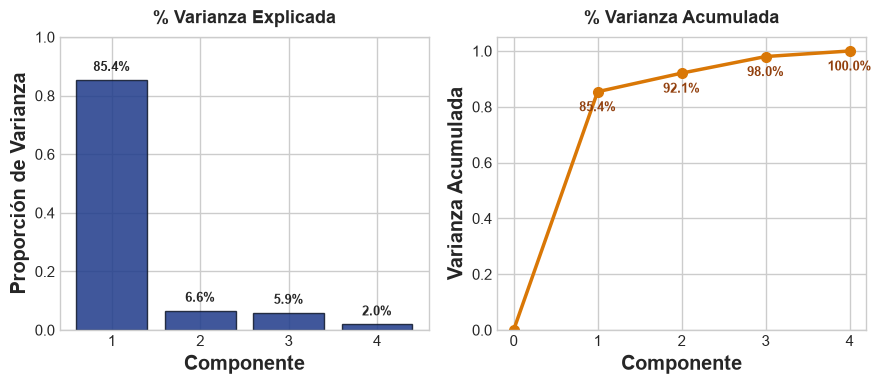

In [5]:
# Visualización de la varianza explicada
plot_variance(pca);


#### 6.6 Puntuaciones de Información Mutua (*Mutual Information*)

Evaluemos la relación entre cada componente principal y el precio del automóvil (`price`):


In [6]:
# Cálculo de puntuaciones MI para los componentes respecto a price
mi_scores = make_mi_scores(X_pca, y, discrete_features=False)
mi_scores


,MI Scores
PC1,1.014401
PC2,0.379175
PC3,0.307170
PC4,0.204934


Observamos que **$PC_1$** es sumamente informativo ($MI > 1.0$), como era de esperarse.

Sin embargo, los componentes restantes (a pesar de representar una fracción menor de la varianza global) conservan una relación significativa con el precio. En particular, **$PC_3$** ($MI \approx 0.31$) expone una dinámica muy interesante:

Ordenemos el conjunto de datos según los valores más altos y más bajos de **$PC_3$**:


In [7]:
# Ordenar el dataset según los valores extremos de PC3
idx = X_pca["PC3"].sort_values(ascending=False).index
cols = ["make", "body_style", "horsepower", "curb_weight"]

df.loc[idx, cols]


,make,body_style,horsepower,curb_weight
118,porsche,hardtop,207,2756
117,porsche,hardtop,207,2756
119,porsche,convertible,207,2800
45,jaguar,sedan,262,3950
96,nissan,hatchback,200,3139
...,...,...,...,...
59,mercedes-benz,wagon,123,3750
61,mercedes-benz,sedan,123,3770
101,peugot,wagon,95,3430
105,peugot,wagon,95,3485


#### 6.7 Creación de una Nueva Característica Derivada: `sports_or_wagon`

Para expresar de forma explícita el contraste identificado por $PC_3$ entre potencia (`horsepower`) y peso (`curb_weight`), creamos una nueva característica mediante un ratio:

$$\text{sports\_or\_wagon} = \frac{\text{horsepower}}{\text{curb\_weight}}$$

Ajustemos un modelo polinomial de grado 2 con `sns.regplot` para visualizar cómo esta característica predice el precio:


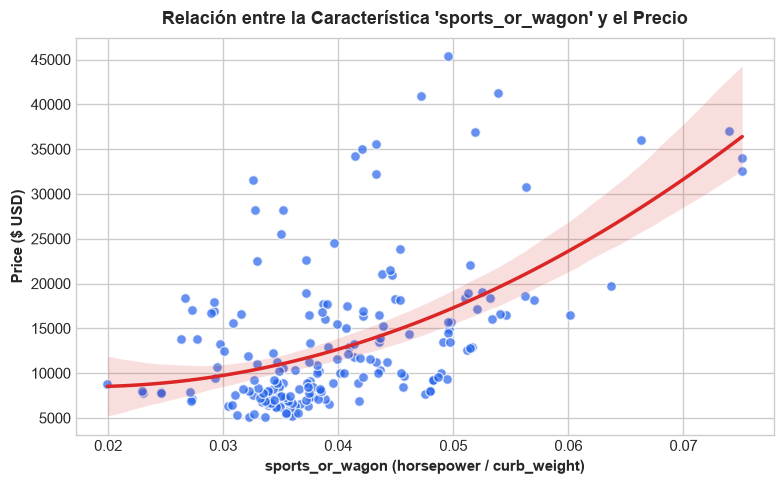

In [8]:
# Creación del nuevo feature derivado del análisis de PCA
df["sports_or_wagon"] = X.horsepower / X.curb_weight

# Gráfico de dispersión y curva de regresión cuadrática
plt.figure(figsize=(8, 5), dpi=100)
sns.regplot(x="sports_or_wagon", y='price', data=df, order=2, color="#1e3a8a",
            scatter_kws={"alpha": 0.7, "color": "#2563eb", "edgecolor": "white", "s": 50},
            line_kws={"color": "#dc2626", "lw": 2.5})

plt.title("Relación entre la Característica 'sports_or_wagon' y el Precio", fontsize=13, fontweight="bold")
plt.xlabel("sports_or_wagon (horsepower / curb_weight)", fontsize=11, fontweight="bold")
plt.ylabel("Price ($ USD)", fontsize=11, fontweight="bold")
plt.show()


---
##### 🛠️ Práctica 1: PCA sobre Dimensiones Físicas y Aerodinámica del Vehículo

Utilizando el DataFrame `df` de automóviles (`autos.csv`):
1. Selecciona las variables de dimensiones físicas: `['length', 'width', 'height', 'curb_weight']`.
2. Estandariza las variables ($Z$-score con media 0 y varianza 1).
3. Ajusta un estimador `PCA()` y calcula las cargas (*loadings*) de los componentes.
4. Calcula las puntuaciones de Información Mutua ($MI$) de cada componente respecto a `price`.
5. Grafica la varianza explicada acumulada y explica qué patrones físicos representan los primeros dos componentes.


In [ ]:
# =========================================================================
# TU SOLUCIÓN AQUÍ:
# =========================================================================
dimension_cols = ["length", "width", "height", "curb_weight"]

# 1. Estandarizar
# X_dim_scaled = ...

# 2. Ajustar PCA
# pca_dim = ...
# X_dim_pca = ...

# 3. Construir la tabla de cargas
# ...

# 4. Calcular MI scores con el precio
# ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1. Selección y estandarización
X_dim = df[["length", "width", "height", "curb_weight"]].copy()
X_dim_scaled = (X_dim - X_dim.mean(axis=0)) / X_dim.std(axis=0)

# 2. Ajuste de PCA
pca_dim = PCA()
X_dim_pca = pca_dim.fit_transform(X_dim_scaled)
dim_comp_names = [f"PC{i+1}" for i in range(X_dim_pca.shape[1])]
X_dim_pca = pd.DataFrame(X_dim_pca, columns=dim_comp_names)

# 3. Cargas (Loadings)
loadings_dim = pd.DataFrame(
    pca_dim.components_.T,
    columns=dim_comp_names,
    index=dimension_cols
)
print("--- Matriz de Cargas (Dimensiones) ---")
display(loadings_dim.round(4))

# 4. Información Mutua con el Precio
mi_dim = make_mi_scores(X_dim_pca, df['price'])
print("
--- Información Mutua con el Precio ---")
print(mi_dim)

# Gráfico de varianza
plot_variance(pca_dim);
```

**Conclusión pedagógica:**
* `PC1` actúa como un **componente de tamaño volumétrico** (todas las cargas son positivas $\approx +0.5$).
* `PC2` y `PC3` capturan **perfil y proporción** (contrastando altura frente a longitud/peso), diferenciando autos deportivos aerodinámicos de carrocerías familiares o utilitarias.
</details>


---
### 7. Resumen y Conclusiones 📌

1. **PCA rota ortogonalmente el espacio de características** para alinearse con los ejes de máxima variación de los datos.
2. **Las cargas (*loadings*)** permiten interpretar qué significa conceptualmente cada componente (ej. *Tamaño vs Forma*, *Lujo vs Economía*, *Deportivo vs Wagon*).
3. **La varianza explicada no equivale a poder predictivo**: componentes de baja varianza pueden contener la señal más determinante para un target específico.
4. **PCA como herramienta de Feature Engineering**:
   * *Descriptiva:* Guía la creación de ratios, productos y combinaciones no lineales.
   * *Transformacional:* Entrega componentes descorrelacionados que reducen la dimensionalidad y el ruido.

---

<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>
